# Домашнее задание #4: исследование линейной регрессииa

### использованный датасет - цены на бу тойоты короллы
https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from scipy.spatial.distance import cosine
import pandas as pd
import time

pd.set_option('display.max_columns', None)


In [69]:
df = pd.read_csv("ToyotaCorolla.csv")

print("Содержимое:\n")
print(df.head(5))

print("\n\nРазмеры:\n")
print(df.shape)

print("\n\nТипы признаков:\n")
print(df.dtypes)

print("\n\nБазовые статистики:\n")
print(df.describe())

print("\n\nСтатистика по категориальным:\n")
print(df.describe(include = ['object']))

print("\n\nПропуски:\n")
print(df.isnull().sum())



Содержимое:

   Id                                          Model  Price  Age_08_04  \
0   1  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
1   2  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
2   3  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
3   4  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
4   5    TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750         30   

   Mfg_Month  Mfg_Year     KM Fuel_Type  HP  Met_Color   Color  Automatic  \
0         10      2002  46986    Diesel  90          1    Blue          0   
1         10      2002  72937    Diesel  90          1  Silver          0   
2          9      2002  41711    Diesel  90          1    Blue          0   
3          7      2002  48000    Diesel  90          0   Black          0   
4          3      2002  38500    Diesel  90          0   Black          0   

     CC  Doors  Cylinders  Gears  Quarterly_Tax  Weight  Mfr_Guarantee  \
0  20

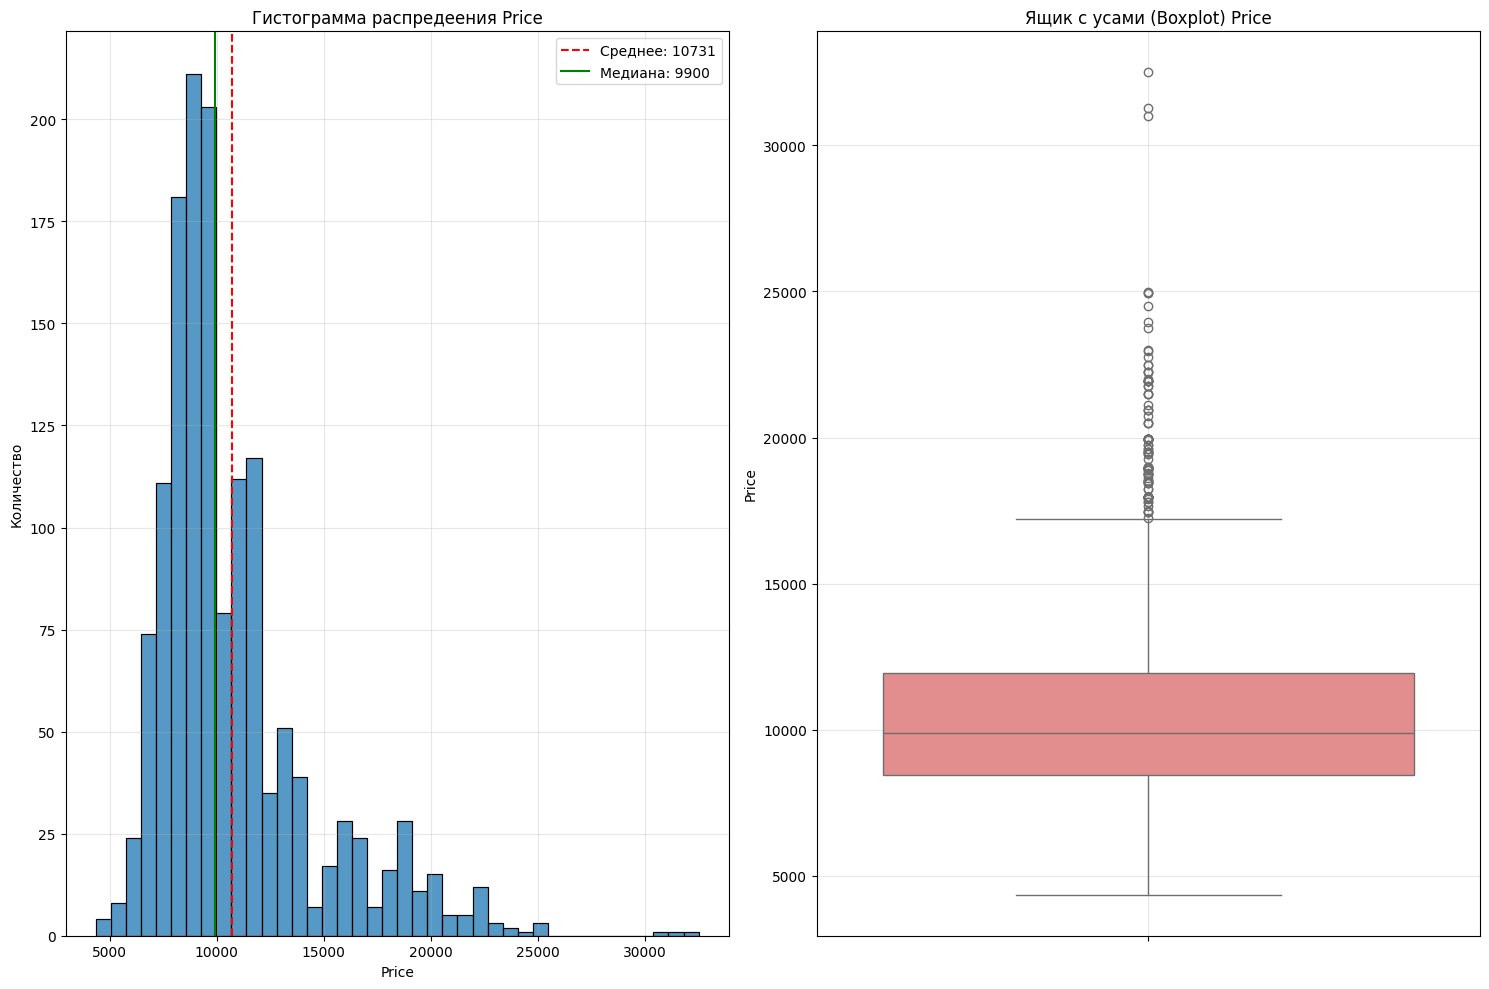

Статистики для Price:
Среднее: 10730.82
Медиана: 9900.00
Дисперсия: 13154872.10
Асимметрия: 1.70
Эксцесс: 3.74


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))


sns.histplot(df['Price'], bins=40, ax=axes[0])
axes[0].set_ylabel('Количество')
axes[0].set_xlabel('Price')
axes[0].set_title('Гистограмма распредеения Price')
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--',
                label=f'Среднее: {df["Price"].mean():.0f}')
axes[0].axvline(df['Price'].median(), color='green', linestyle='-',
                label=f'Медиана: {df["Price"].median():.0f}')
axes[0].grid(True, alpha=0.3)
axes[0].legend()


sns.boxplot(y=df['Price'], ax=axes[1], color='LightCoral')
axes[1].set_title('Ящик с усами (Boxplot) Price')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("Статистики для Price:")
print(f"Среднее: {df['Price'].mean():.2f}")
print(f"Медиана: {df['Price'].median():.2f}")
print(f"Дисперсия: {df['Price'].var():.2f}")
print(f"Асимметрия: {(df['Price']).skew():.2f}")
print(f"Эксцесс: {(df['Price']).kurtosis():.2f}")

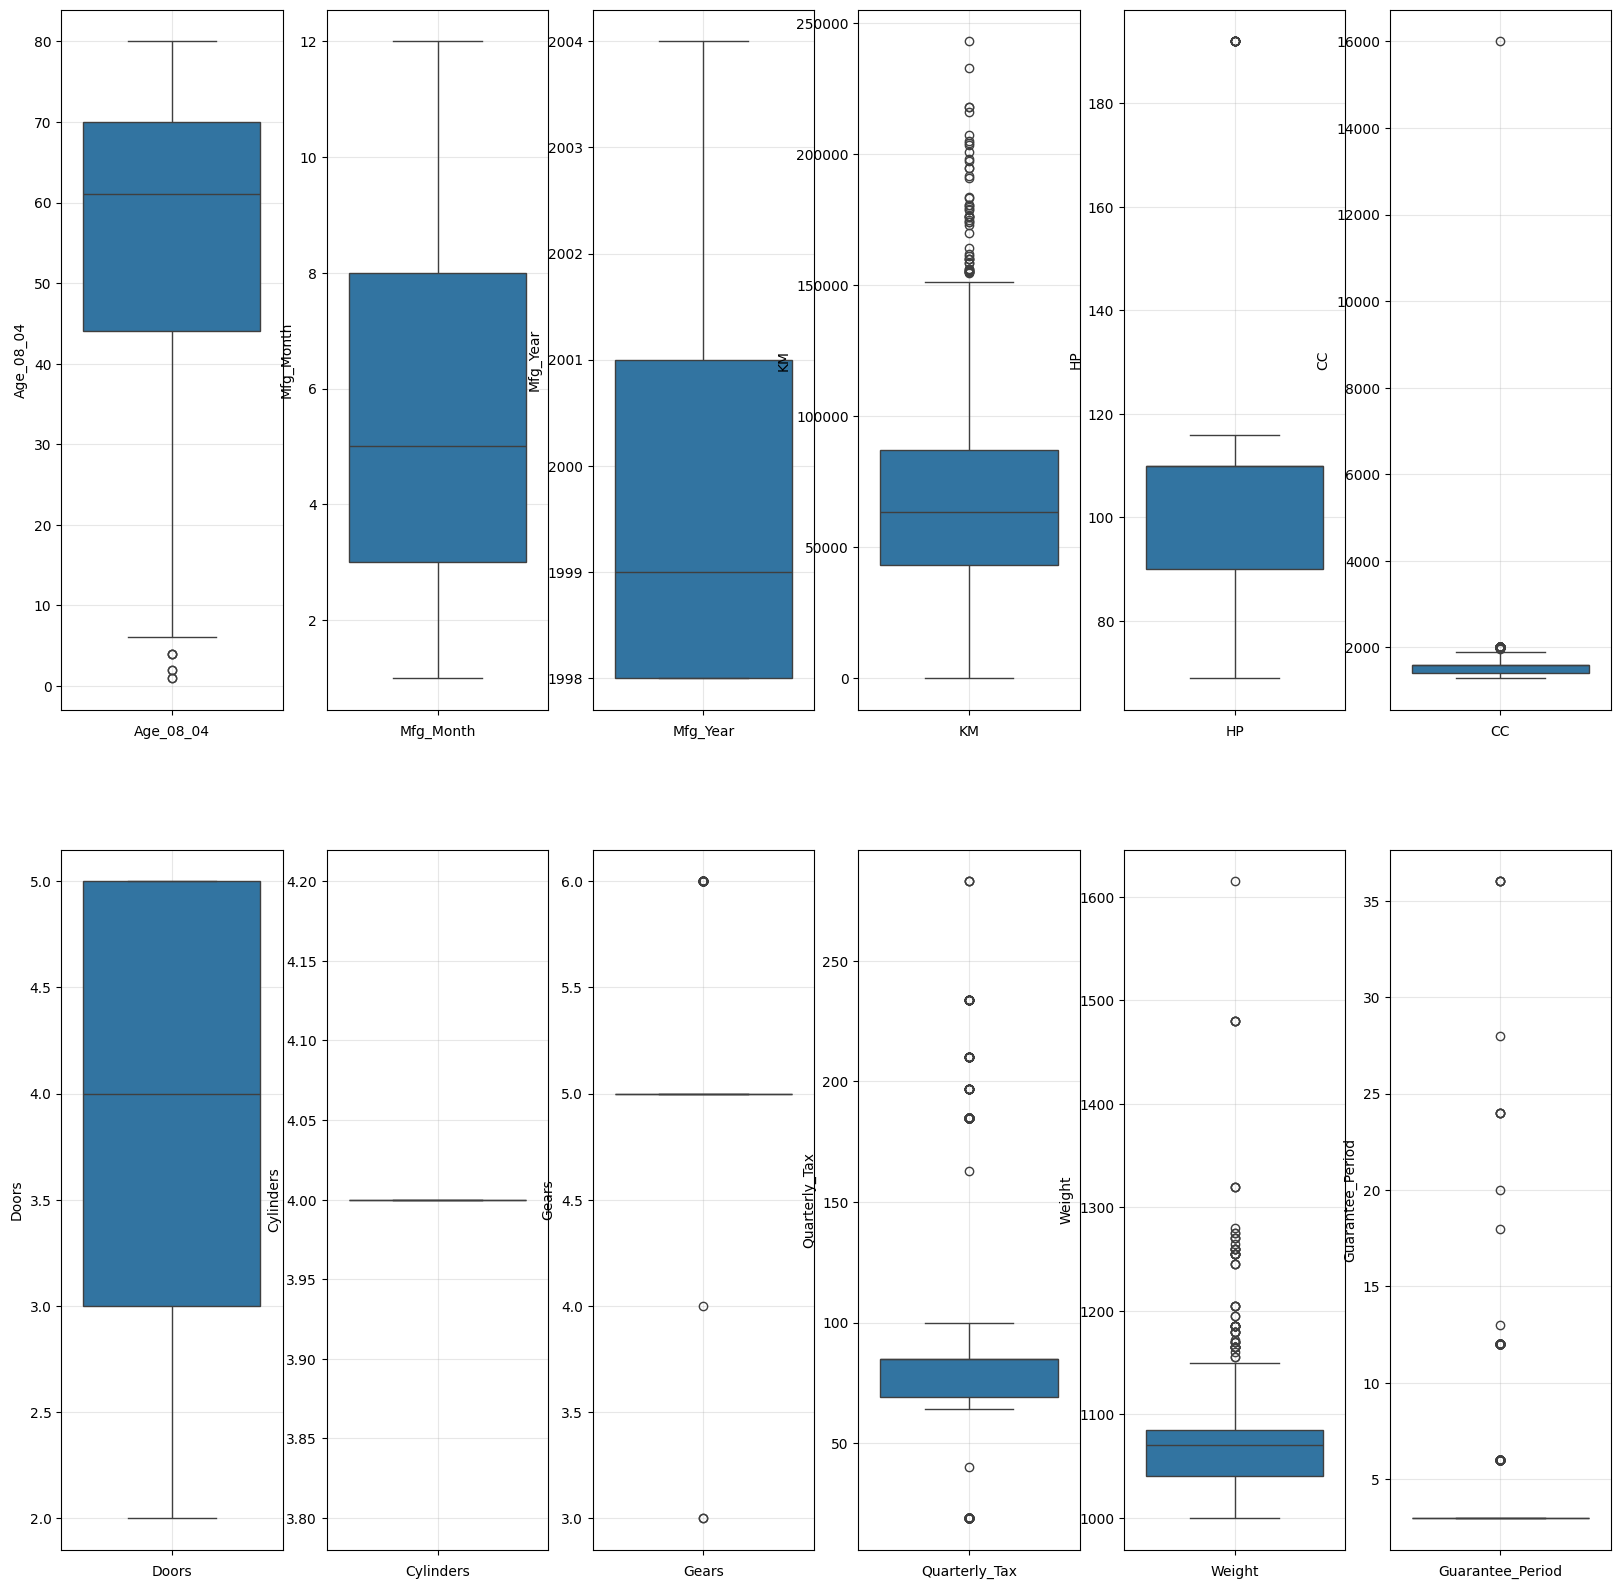

In [71]:
num_features = ['Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Guarantee_Period']

fig, axes = plt.subplots(2, 6, figsize=(20, 20))
axes = axes.ravel()

for i, feature in enumerate(num_features):
    sns.boxplot(y=df[num_features[i]], ax=axes[i])
    axes[i].set_xlabel(num_features[i])
    axes[i].grid(True, alpha=0.3)

Наблюдаем странный выброс в объеме двигателя(16 литров в корлле). Удалим запись.
так же смущает вес некоторого экземпляра >1.6 тонны.

In [72]:
df = df[df['CC'] <= 3000]


Проверим вес. Вероятно ошибка с одной из записей. Возможно указана полная масса вместо снаряженной. удалим запись

In [73]:
df[df['Weight'] > 1500]

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
221,223,TOYOTA Corolla 1.6 HB LINEA SOL 4/5-Doors,12450,44,1,2001,74172,Petrol,110,1,Black,0,1600,5,4,5,163,1615,1,1,3,0,1,0,1,0,0,1,1,1,1,0,0,0,1,0,0,0,0


In [74]:
df = df[df['Weight'] <= 1600]

Аналогично стоит проверить одинокие варианты с количеством передач 3 или 4. Вероятно аномалии(3 передачи и подавно не для конца 90х начала 00х)

In [75]:
df[df['Gears'] < 5]


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
956,960,TOYOTA Corolla 1.6 Linea Luna Aut. 4/5-Doors,10950,58,11,1999,51421,Petrol,110,0,Silver,1,1600,5,4,3,85,1105,0,0,6,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0
991,996,TOYOTA Corolla 1.6 Lin.Terra Aut. 4/5-Doors,7950,58,11,1999,43000,CNG,110,1,Silver,1,1600,4,4,3,72,1114,0,0,3,1,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0
1426,1433,TOYOTA Corolla 1.6 Lin.Terra Aut. 2/3-Doors,9950,78,3,1998,30964,Petrol,110,0,Silver,1,1600,3,4,4,85,1080,1,1,12,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [76]:
df = df[df['Gears'] > 4]

Еще раз демонстрация ящиков с усами(после удаления выбросов в рассмотренных категориях)

6 передач и 192 лс это не выбросы. такие заряженные версии реально были(двигатель 1.8)

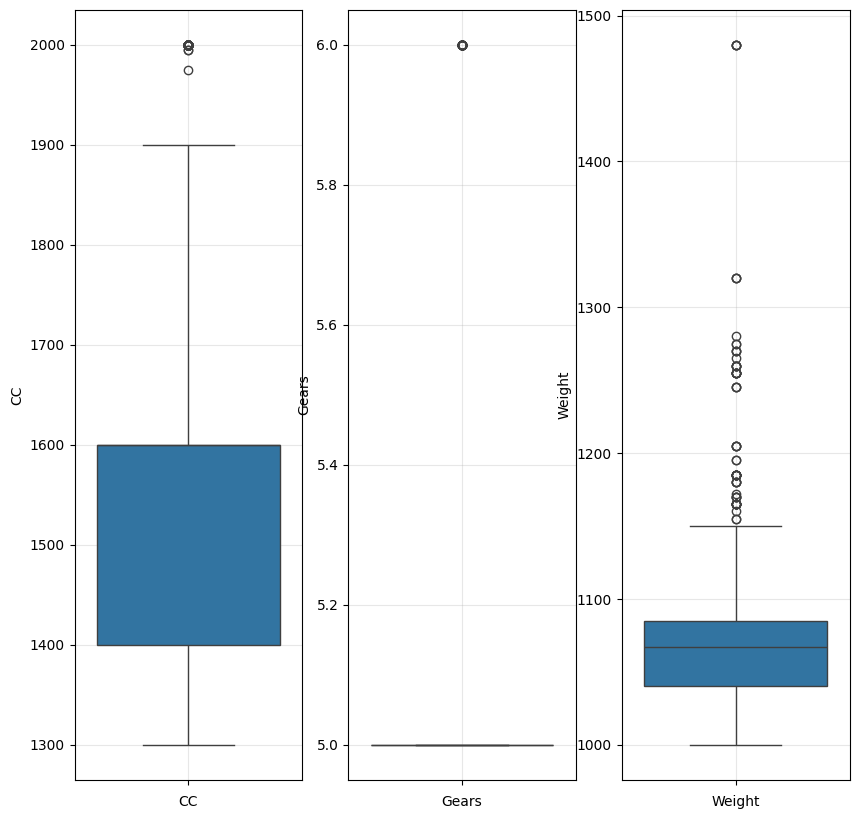

In [77]:
num_features = ['CC', 'Gears', 'Weight']

fig, axes = plt.subplots(1, 3, figsize=(10, 10))
axes = axes.ravel()

for i, feature in enumerate(num_features):
    sns.boxplot(y=df[num_features[i]], ax=axes[i])
    axes[i].set_xlabel(num_features[i])
    axes[i].grid(True, alpha=0.3)

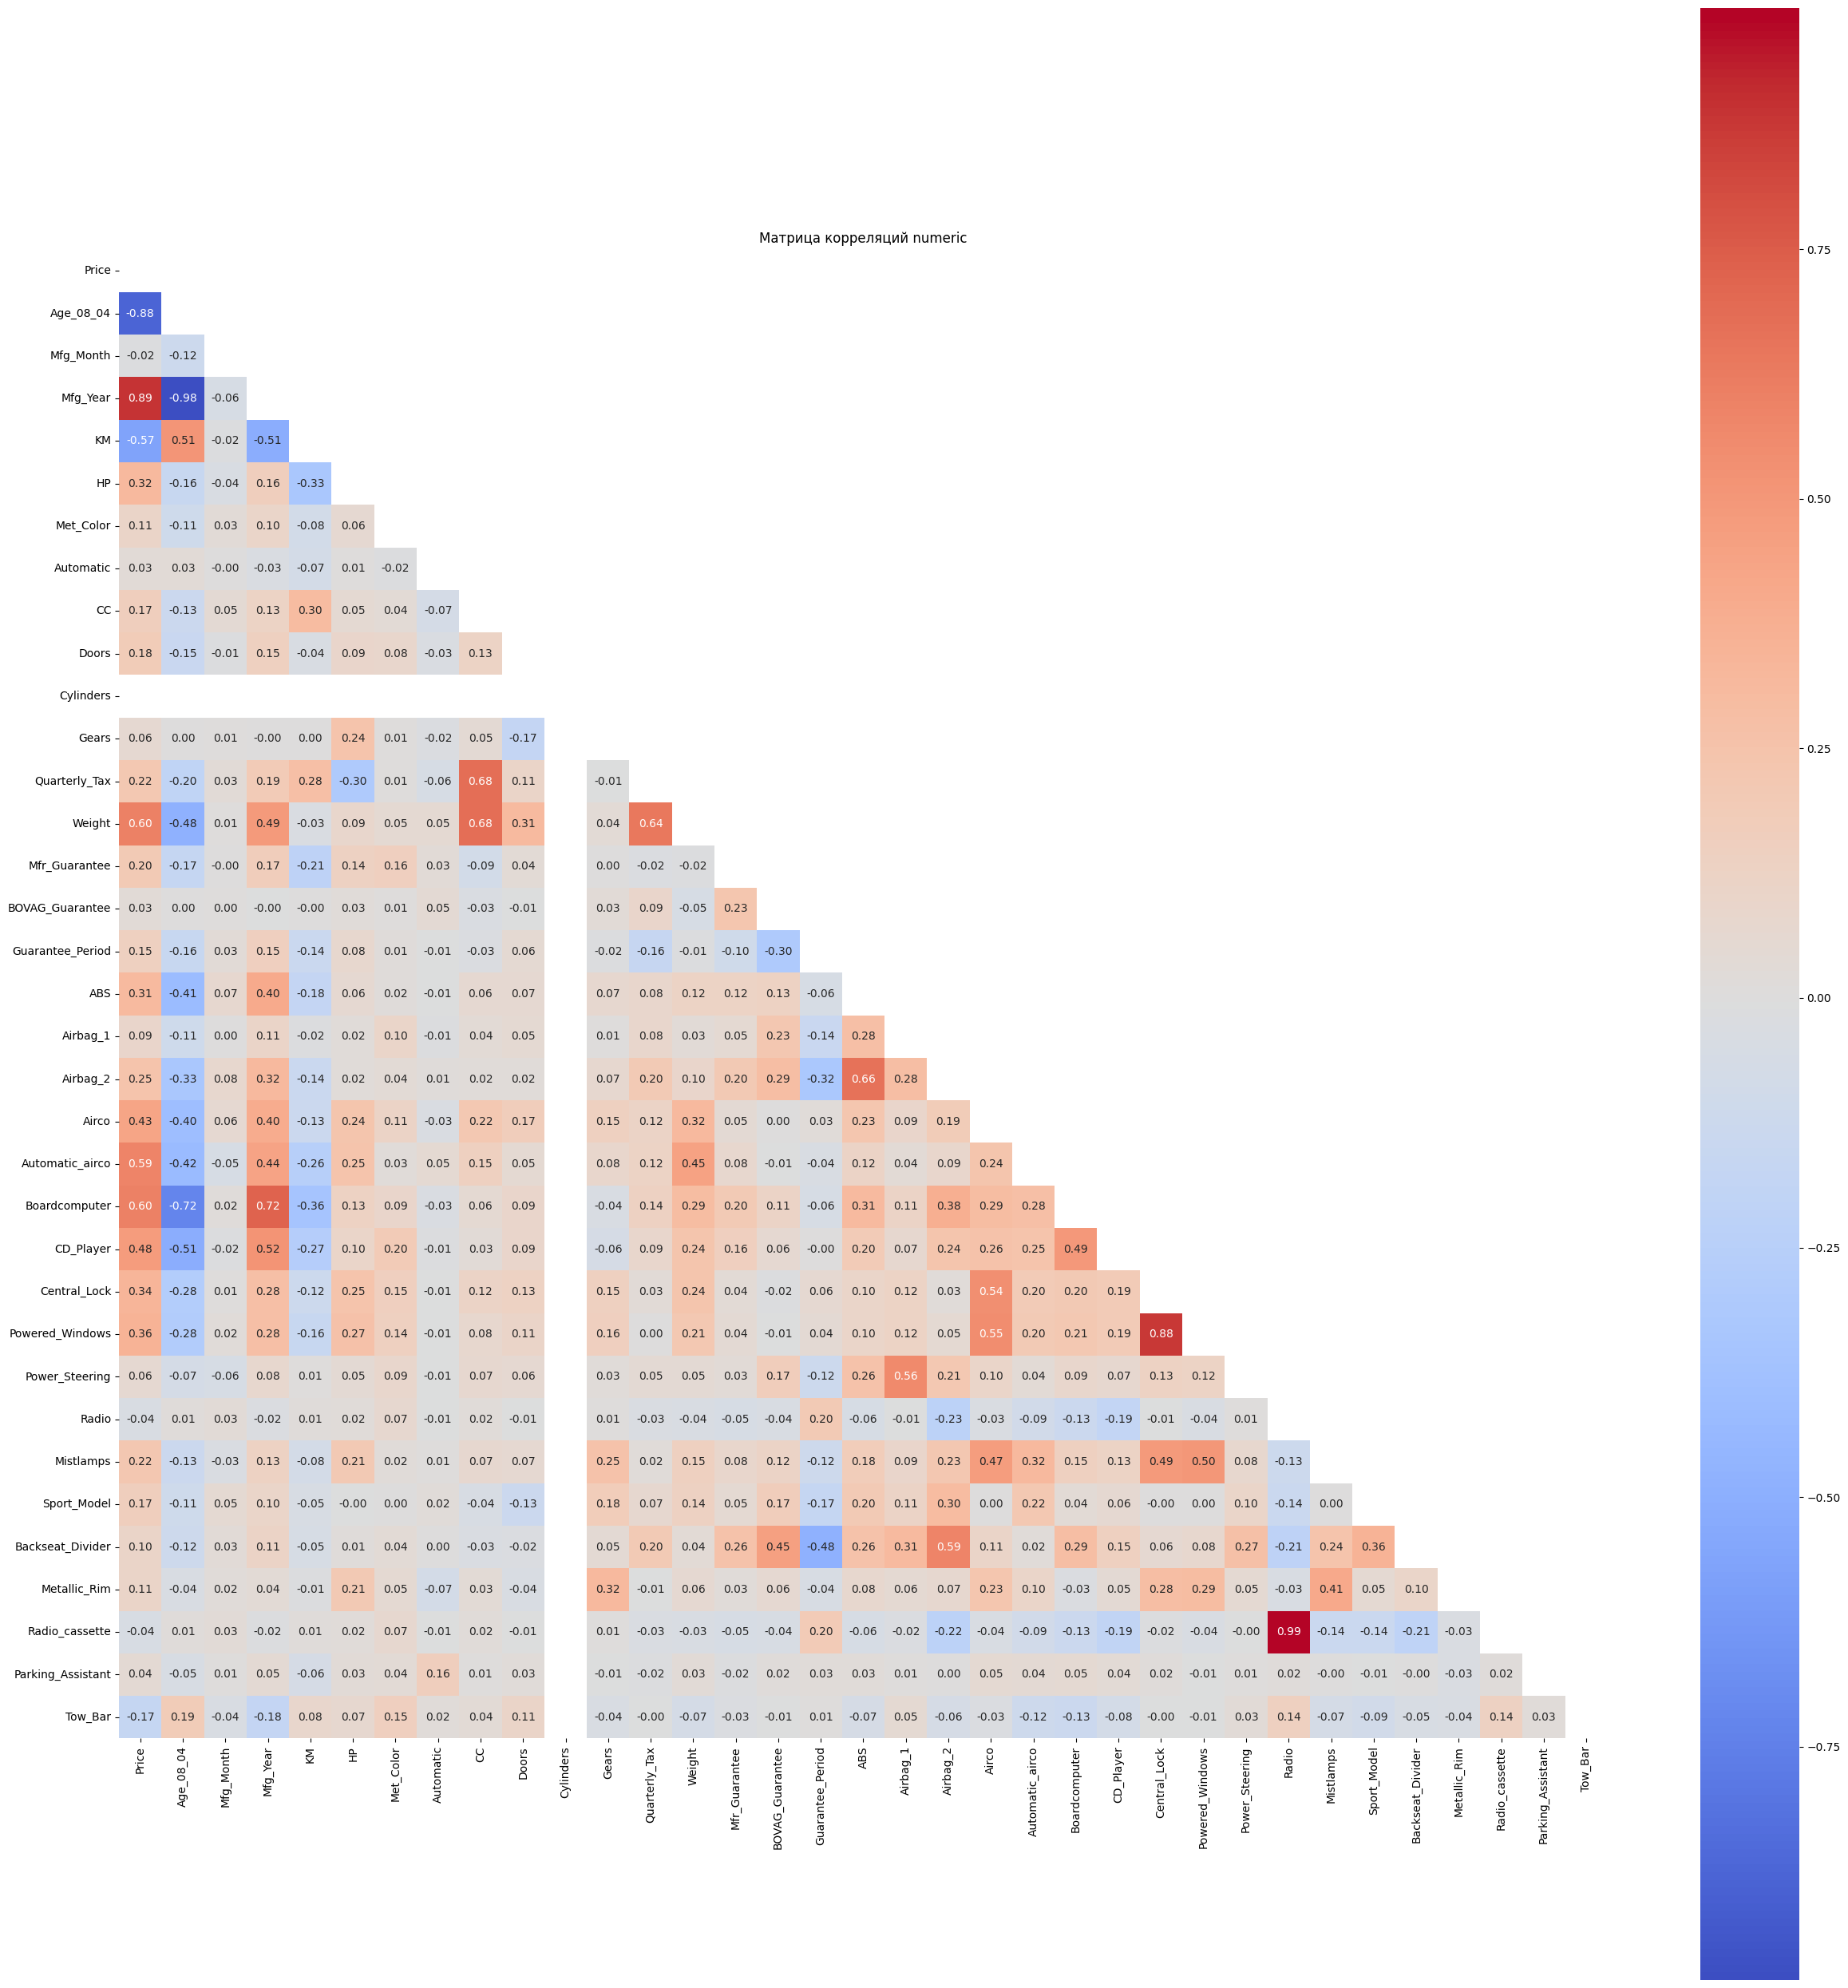

In [78]:

numeric_cols = df.select_dtypes(include=['int64']).columns

if 'Id' in numeric_cols:
  numeric_cols = numeric_cols.drop('Id')

plt.figure(figsize=(25, 25))
correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Матрица корреляций numeric')
plt.tight_layout()
plt.show()



Топ-10 признаков коррелиации с Price:
Mfg_Year: 0.885
Age_08_04: 0.877
Boardcomputer: 0.604
Weight: 0.600
Automatic_airco: 0.586
KM: 0.570
CD_Player: 0.480
Airco: 0.429
Powered_Windows: 0.356
Central_Lock: 0.343


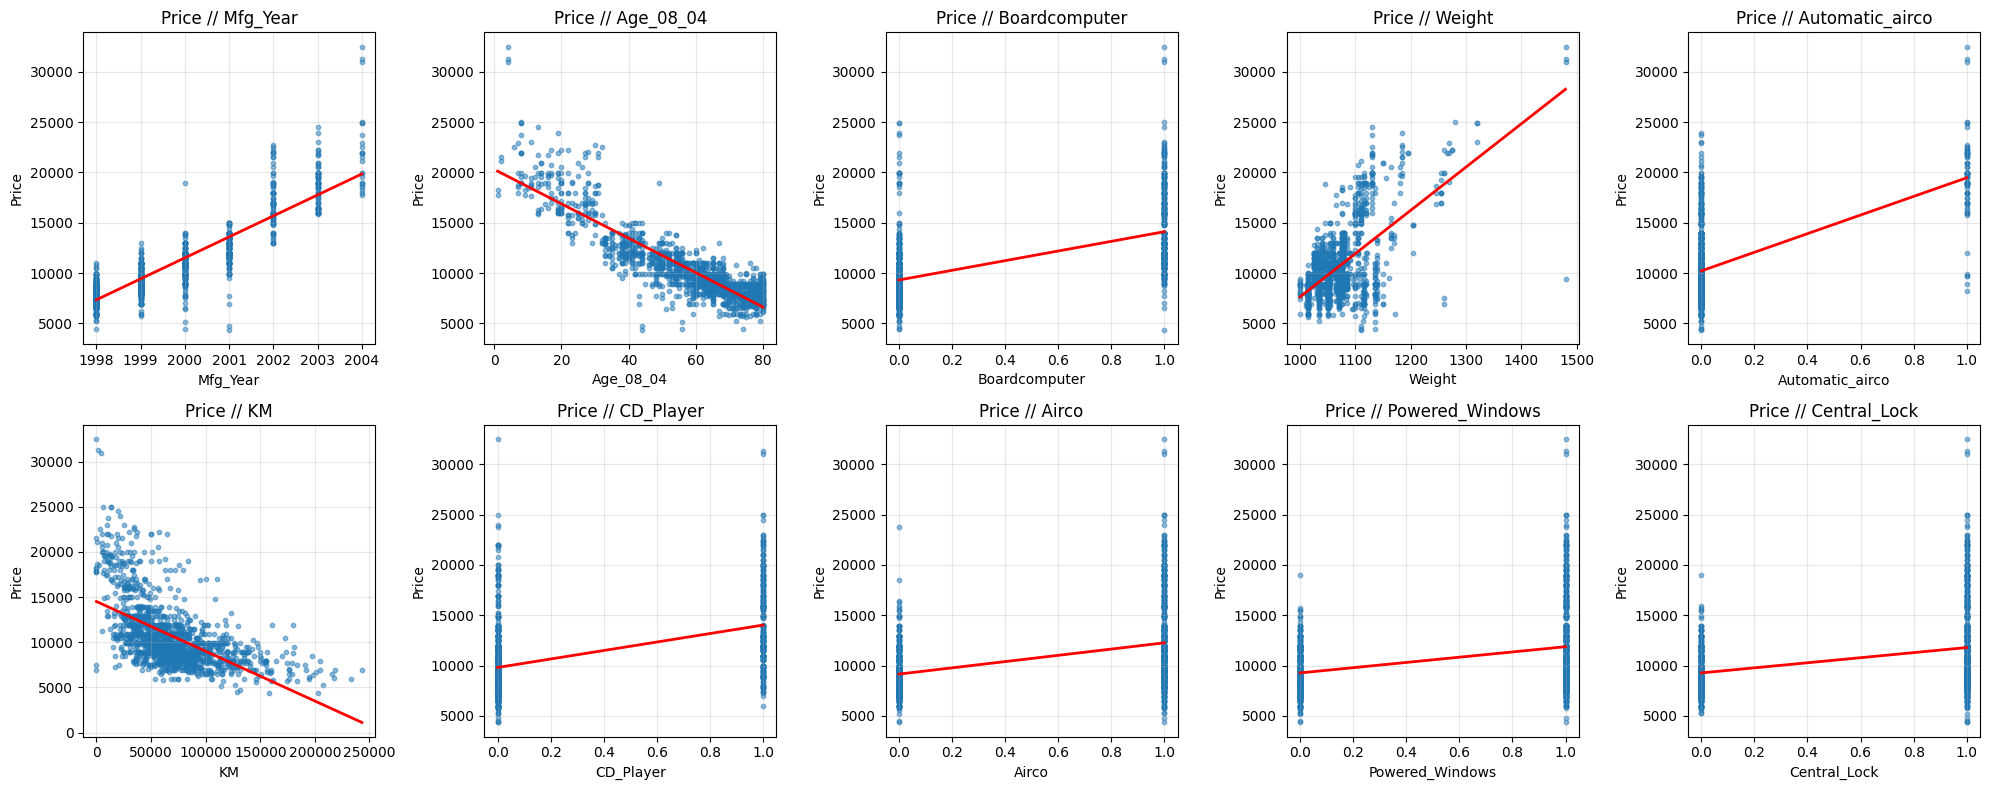

In [79]:
corr_with_price = df[numeric_cols].corr()['Price'].abs().sort_values(ascending=False)

top_10_features = corr_with_price.index[1:11]
print("Топ-10 признаков коррелиации с Price:")
for feat in top_10_features:
    print(f"{feat}: {corr_with_price[feat]:.3f}")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, feature in enumerate(top_10_features):
    axes[i].scatter(df[feature], df['Price'], alpha=0.5, s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'Price // {feature}')
    axes[i].grid(True, alpha=0.3)

    z = np.polyfit(df[feature], df['Price'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[feature].sort_values(),
                 p(df[feature].sort_values()),
                 color='red', linewidth=2)

plt.tight_layout()
plt.show()

Категориальные признаки:
(без учёта бинарных. ибо на графиках выше видна зависимость для наиболее коррелируемых с ценой)

Object-признаки: ['Model', 'Fuel_Type', 'Color']

Model
Уникальных значений: 314

15 самых частых значений:
Model
TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-Doors      109
TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors       84
TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA 4/5-Doors         80
TOYOTA Corolla 1.6 16V LIFTB LINEA TERRA 4/5-Doors        71
TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-Doors       54
TOYOTA Corolla 1.6 16V SEDAN LINEA TERRA 4/5-Doors        43
TOYOTA Corolla 1.6 16V VVT I LIFTB TERRA 4/5-Doors        37
TOYOTA Corolla 1.3 16V LIFTB LINEA TERRA 4/5-Doors        35
TOYOTA Corolla 1.6 16V VVT I LIFTB SOL 4/5-Doors          35
TOYOTA Corolla 1.6 16V WAGON LINEA TERRA Stationwagen     28
TOYOTA Corolla 2.0 DSL HATCHB LINEA TERRA 2/3-Doors       25
TOYOTA Corolla 1.6 16V VVT I LIFTB LUNA 4/5-Doors         23
TOYOTA Corolla 1.4 16V VVT I LIFTB TERRA 4/5-Doors        23
TOYOTA Corolla 1.6 16V VVT I HATCHB TERRA 2/3-Doors       22
TOYOTA Corolla 1.6 16V VVT I 5DR

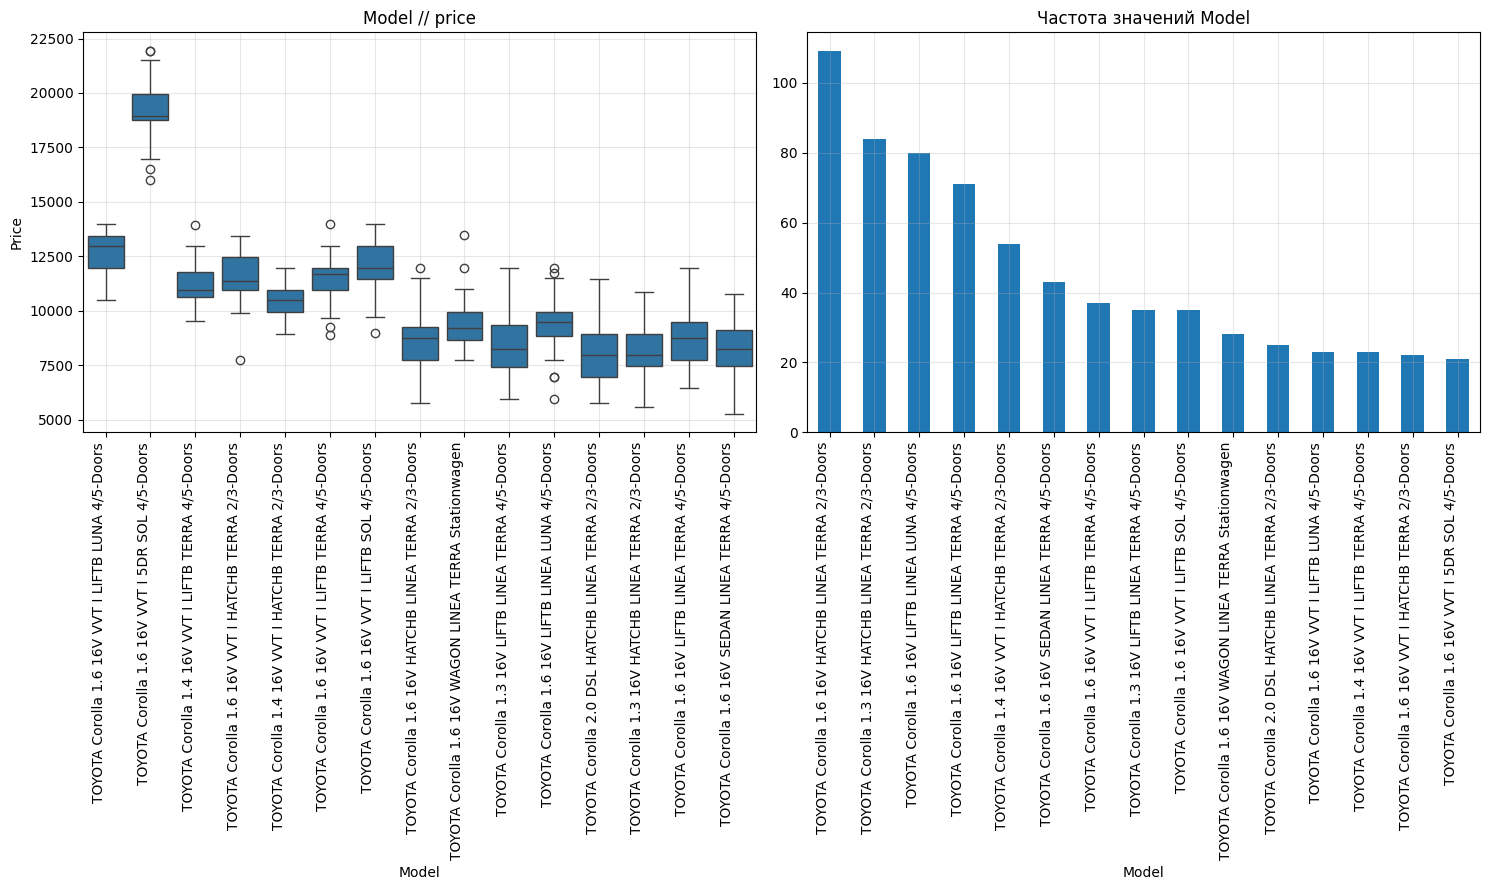


Fuel_Type
Уникальных значений: 3

Самые частые значения:
Fuel_Type
Petrol    1260
Diesel     155
CNG         16
Name: count, dtype: int64


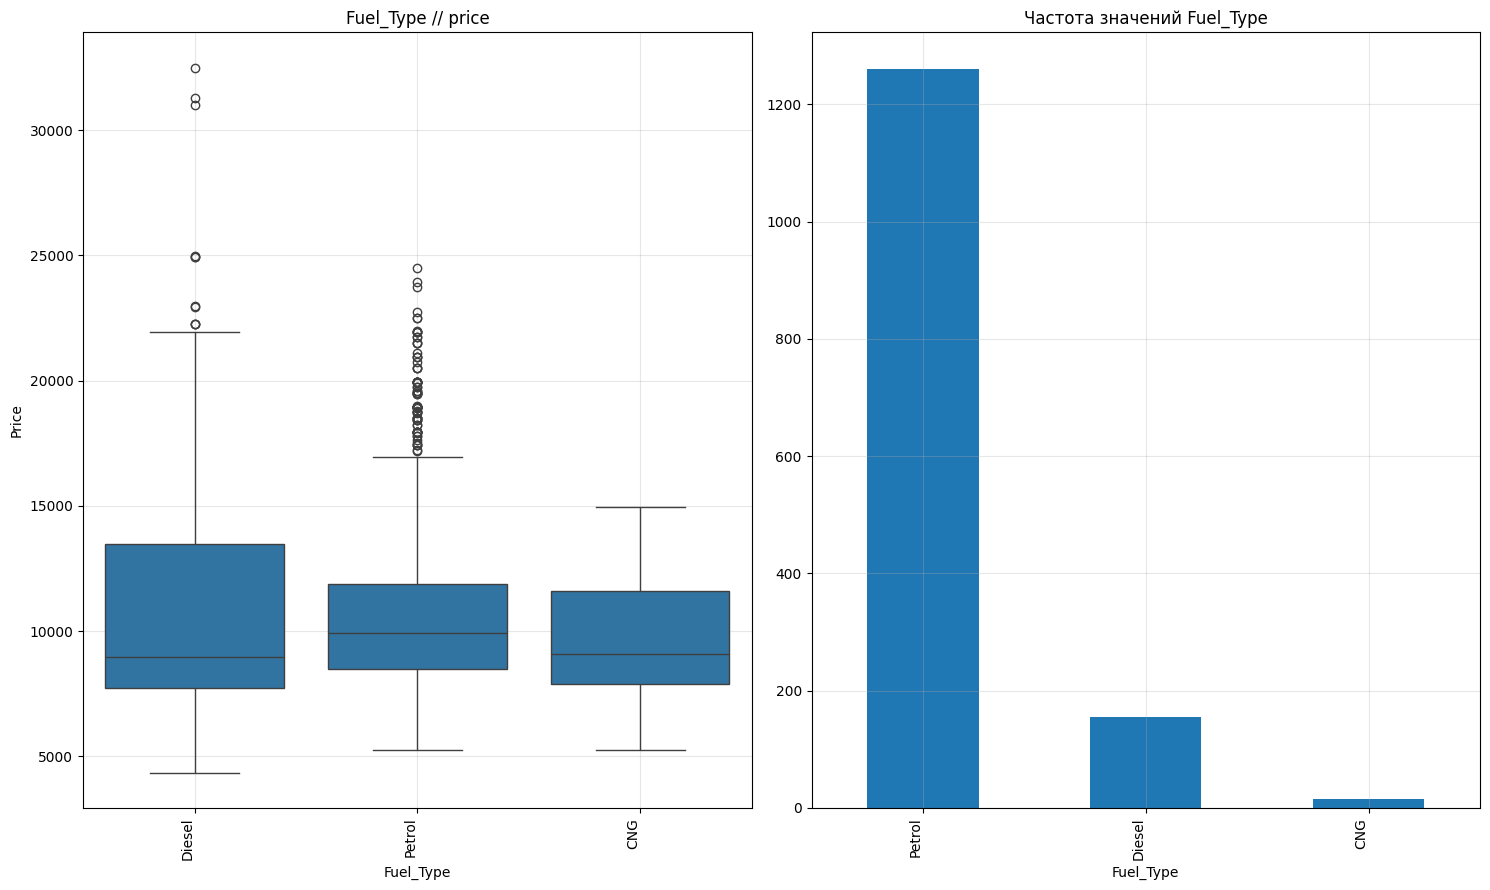


Color
Уникальных значений: 10

Самые частые значения:
Color
Grey      301
Blue      282
Red       278
Green     220
Black     190
Silver    119
White      31
Violet      4
Yellow      3
Beige       3
Name: count, dtype: int64


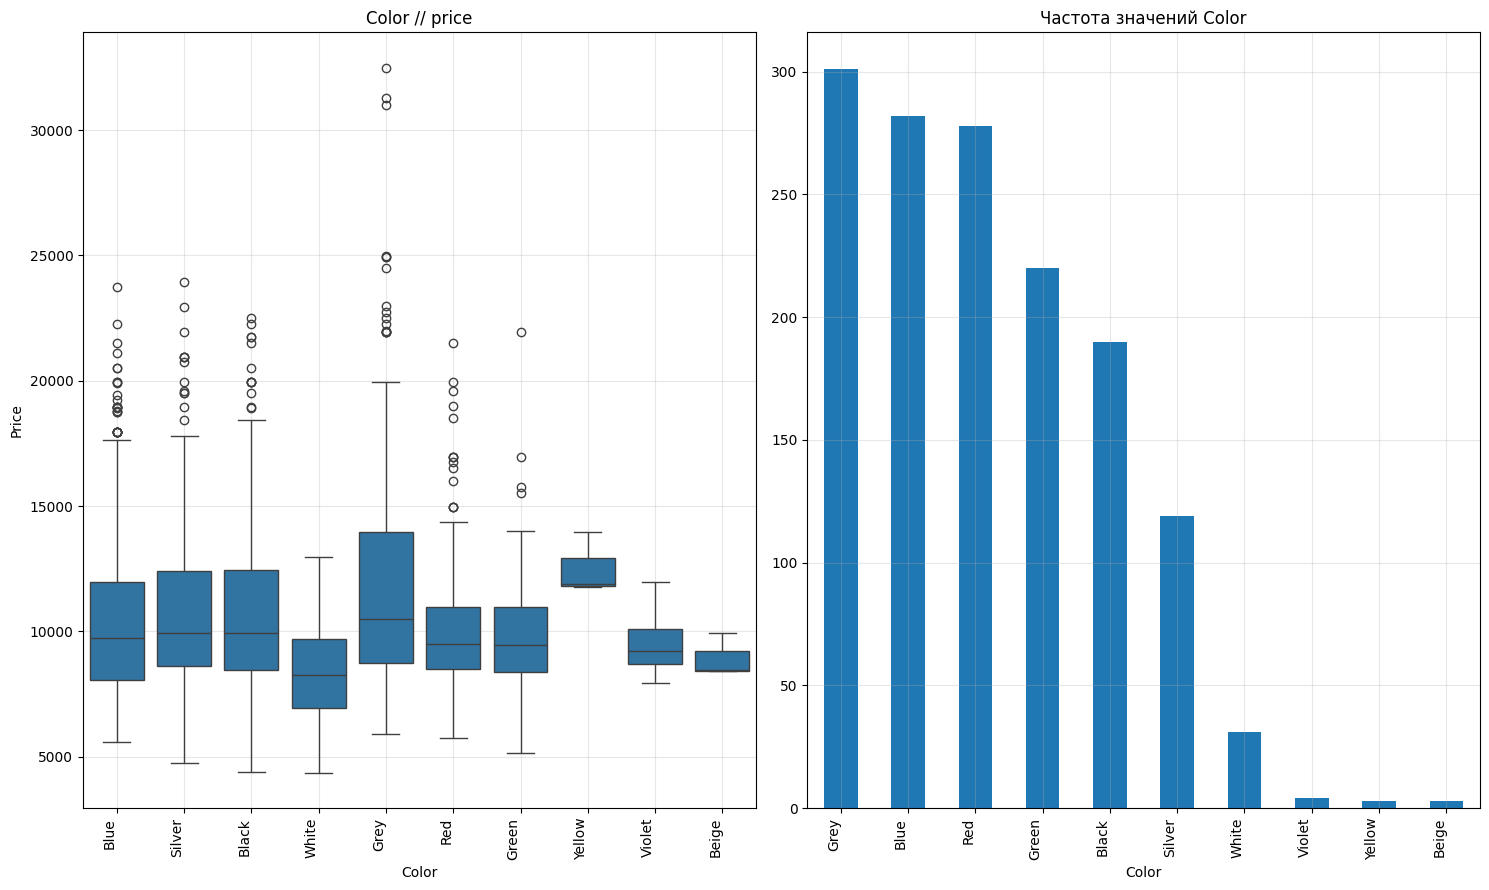

In [80]:
cat_cols = df.select_dtypes(include=['object']).columns
print("Object-признаки:", list(cat_cols))

for col in cat_cols:
    print(f"\n{col}")
    print(f"Уникальных значений: {df[col].nunique()}")
    amount = 10
    if df[col].nunique() > 15:
      print("\n15 самых частых значений:")
      amount = 15
    else:
      print("\nСамые частые значения:")

    print(df[col].value_counts().head(amount))
    plt.figure(figsize=(15, 9))


    plt.subplot(1, 2, 1)
    top_cats = df[col].value_counts().head(amount).index
    data_plot = df[df[col].isin(top_cats)]
    sns.boxplot(x=col, y='Price', data=data_plot)
    plt.xticks(rotation=90, ha='right')
    plt.title(f'{col} // price')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    df[col].value_counts().head(15).plot(kind='bar')
    plt.title(f'Частота значений {col}')
    plt.xticks(rotation=90, ha='right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# FEATURE ENGENEERING
новый признак - среднегодовой пробег(он оказался бесполезен. на тренировочной выборке результат становился чуть лучше а на тестовой чуть хуже. порядка 1 тысячной по метрике R2) принял решение отказаться

one-hot-encoding для типа топлива и цвета(3 и 10 уникальных значений соотв.)

In [81]:
#df['KM_per_Year'] = ((df['KM'] * 12) / (df['Age_08_04'])).round(1) - отказался. приводит к переобучению

fuel_dummies = pd.get_dummies(df['Fuel_Type'], prefix='Fuel')
df = pd.concat([df, fuel_dummies], axis=1)

color_dummies = pd.get_dummies(df['Color'], prefix='Color')
df = pd.concat([df, color_dummies], axis=1)



удлание ненужных и сильно коррелирующих между собой признаков(по матрице коррелиаций)

In [82]:
cols_to_drop = [
    'Id',
    'Model', #слишком много уникальных. вытаскивать тип кузова(лифтбек или универсал)
    #мало смысла т.к. это отражается количеством дверей
    #вытаскивать комплектацию типа terra luna sol.. тоже нет смысла ведь полнота комплектации
    # кодируется бинарными признаками типо автоматического климата и тд
    'Mfg_Year', # высокая корреляция c Age
    'Mfg_Month', # зачем месяц без года
    'Cylinders', # все короллы четырехкотловые
    'Color', # сделали кодирование
    'Fuel_Type', # сделали кодирование
    'Radio_cassette', # высокая корреляция с Radio
    'Central_Lock' # высокая корреляция с электростеклоподъемниками. удалил центральный замок
    # т.к. стеклоподъемники больше коррелируют с ценой
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# ПРОМЕЖУТОЧНЫЕ ВОПРОСЫ
**Как вы предобрабатывали данные?**

удалил выбросы(смотреть выше) вообще вопрос свзян с вопросом ниже

**Что вы поняли, проведя EDA?**

цена в основном зависит от возраста и пробега(и наличие автоматического климат контроля)

**Как вы работали с признаками?**
Кодировал и/или удалял

**Какие признаки вы добавили / изменили и почему?**

Закодировал категориальные признаки типа товлива и цвета(смотреть выше). Признак который добавил лучше не сделал


**Какие признаки вы удалили и почему?**
смотреть ячеку с кодом выше. там комментарии



# РАЗБИЕНИЕ И МАСШТАБИРОВАНИЕ

In [83]:
y = df['Price']
X = df.drop('Price', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Как именно вы разделили выборку?**

С помощью train_test_split. 80% данных на обучение. 20% на тестирование

**Для чего это нужно?** Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?

Для того чтобы проверить работоспособность модели на данных которые она не видела до этого. Если обучать модель на всех данных не получится объективного результата т.к. модель может переобучиться.


# ОБУЧЕНИЕ МОДЕЛИ И ПОДБОР ГИПЕРПАРАМЕТРОВ

In [84]:
import time

start_time = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
end_time = time.time()
print(f"Время обучения LinearRegression: {end_time - start_time:.4f} s")

ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
start_time = time.time()
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)
end_time = time.time()
print(f"Время обучения Ridge: {end_time - start_time:.4f} s")
print(f"Лучшая alpha для Ridge: {ridge_grid.best_params_}")

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
start_time = time.time()
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)
end_time = time.time()
print(f"Время обучения Lasso: {end_time - start_time:.4f} s")
print(f"Лучшая alpha для Lasso: {lasso_grid.best_params_}")

Время обучения LinearRegression: 0.0069 s
Время обучения Ridge: 0.1713 s
Лучшая alpha для Ridge: {'alpha': 10.0}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.154e+07, tolerance: 1.213e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.272e+07, tolerance: 1.087e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.219e+07, tolerance: 1.115e

Время обучения Lasso: 3.4025 s
Лучшая alpha для Lasso: {'alpha': 10.0}


По времени выполнения видно что просто LinearRegression обучилась быстрее остальных.
Lasso и Ridge обучлись дольше изза водбора гиперпарметра. Lasso в целом кратно дольше.

# Проверка на тестовой выборке

In [85]:
models = {
    'Linear Regression': lr,
    'Ridge': ridge_grid.best_estimator_,
    'Lasso': lasso_grid.best_estimator_
}

for name, model in models.items():
    y_train_pred = model.predict(X_train_scaled)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    print(f"{name}:")
    print(f"RMSE: {train_rmse:.2f}")
    print(f"MAE: {train_mae:.2f}")
    print(f"R2: {train_r2:.3f}")
    print()

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.3f}")

Linear Regression:
RMSE: 1079.56
MAE: 808.82
R2: 0.913

Ridge:
RMSE: 1080.40
MAE: 807.83
R2: 0.913

Lasso:
RMSE: 1082.77
MAE: 808.96
R2: 0.913


Linear Regression:
RMSE: 1091.25
MAE: 845.54
R2: 0.903

Ridge:
RMSE: 1091.23
MAE: 846.52
R2: 0.903

Lasso:
RMSE: 1084.99
MAE: 843.35
R2: 0.904


# Финальные вопросы

1. **Какие метрики вы использовали для сравнения моделей?** (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен
$R^2$?)

У меня представлены все три метрики.

RMSE показывает чему в среднем равна квадратичная ошибка. и такая метрика чувтивтельна к выбросам.

MAE грубо говоря показывает среднюю ошибку.
В моем случае наверное более предпочтительно использование MAE т.к. среди данных присутствуют редкие модели(а ля 192 hp/6 передач и тд) которые ЯВЛЯЮТСЯ данными

2. **На какой части выборки вы считали метрики?**

на обеих. и на обучающей и на тестовой. информация мне понадобилась для ответа на последний вопрос.

3. **Какая модель по итогу справилась лучше?**

Лучше всех справилась модель Lasso с альфа=10

4. Насколько хорошие получились результаты?

R2 = 0.904

MAE = 843.35 доллара

думаю нормальный результат

5. Чем докажете, что ваша модель не переобучилась?

тестовые показания **незначительно** отличаются от тренировочных. поэтому метрики и считались на обеих выборказ.
